# 

# Leitura do CSV para dataframe

In [26]:
import polars as pl
import numpy as np

np.random.seed(42)

df_base = pl.read_csv("flights.csv")
df_base.head()

YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
i64,i64,i64,i64,str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64
2015,1,1,4,"""AS""",98,"""N407AS""","""ANC""","""SEA""",5,2354,-11,21,15,205,194,169,1448,404,4,430,408,-22,0,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",2336,"""N3KUAA""","""LAX""","""PBI""",10,2,-8,12,14,280,279,263,2330,737,4,750,741,-9,0,0,null,null,null,null,null,null
2015,1,1,4,"""US""",840,"""N171US""","""SFO""","""CLT""",20,18,-2,16,34,286,293,266,2296,800,11,806,811,5,0,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",258,"""N3HYAA""","""LAX""","""MIA""",20,15,-5,15,30,285,281,258,2342,748,8,805,756,-9,0,0,null,null,null,null,null,null
2015,1,1,4,"""AS""",135,"""N527AS""","""SEA""","""ANC""",25,24,-1,11,35,235,215,199,1448,254,5,320,259,-21,0,0,null,null,null,null,null,null


# Dataframe sem os voo cancelados

In [27]:
len_ini = len(df_base)
df_base = df_base.filter(pl.col("CANCELLATION_REASON").is_null())
print(f'Initial shape: {len_ini}, Final shape: {df_base.shape[0]}', f'({len_ini - df_base.shape[0]} rows removed due to cancellations)')
df_base.head()

Initial shape: 5819079, Final shape: 5729195 (89884 rows removed due to cancellations)


YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
i64,i64,i64,i64,str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64
2015,1,1,4,"""AS""",98,"""N407AS""","""ANC""","""SEA""",5,2354,-11,21,15,205,194,169,1448,404,4,430,408,-22,0,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",2336,"""N3KUAA""","""LAX""","""PBI""",10,2,-8,12,14,280,279,263,2330,737,4,750,741,-9,0,0,null,null,null,null,null,null
2015,1,1,4,"""US""",840,"""N171US""","""SFO""","""CLT""",20,18,-2,16,34,286,293,266,2296,800,11,806,811,5,0,0,null,null,null,null,null,null
2015,1,1,4,"""AA""",258,"""N3HYAA""","""LAX""","""MIA""",20,15,-5,15,30,285,281,258,2342,748,8,805,756,-9,0,0,null,null,null,null,null,null
2015,1,1,4,"""AS""",135,"""N527AS""","""SEA""","""ANC""",25,24,-1,11,35,235,215,199,1448,254,5,320,259,-21,0,0,null,null,null,null,null,null


# Preparação da tabela para análises
Conversão das colunas de data/para _timestamp_ e as variáveis de dia da semana para variáveis categóricas

In [28]:
def hhmm_to_duration(col_name):
    """Convert an HHMM integer (e.g. 5 → 00:05, 2354 → 23:54) to a Polars duration."""
    val = pl.col(col_name).cast(pl.Int64)
    return pl.duration(hours=val // 100, minutes=val % 100)

# Tratamento de datas e horas int usando Polars
base_date = pl.date(pl.col("YEAR"), pl.col("MONTH"), pl.col("DAY")).cast(pl.Datetime("us"))
df_base = (
    df_base
    # 1. Scheduled departure: base date + HHMM offset
    .with_columns(
        (base_date + hhmm_to_duration("SCHEDULED_DEPARTURE")).alias("SCHEDULED_DEPARTURE_DT")
    )
    # 2. Actual departure and scheduled arrival (both derived from scheduled departure)
    .with_columns(
        (pl.col("SCHEDULED_DEPARTURE_DT") + pl.duration(minutes=pl.col("DEPARTURE_DELAY").cast(pl.Int64))).alias("DEPARTURE_TIME_DT"),
        (pl.col("SCHEDULED_DEPARTURE_DT") + pl.duration(minutes=pl.col("SCHEDULED_TIME").cast(pl.Int64))).alias("SCHEDULED_ARRIVAL_DT"),
    )
    # 3. Wheels off: actual departure + taxi out
    .with_columns(
        (pl.col("DEPARTURE_TIME_DT") + pl.duration(minutes=pl.col("TAXI_OUT").cast(pl.Int64))).alias("WHEELS_OFF_DT"),
    )
    # 4. Wheels on: wheels off + air time
    .with_columns(
        (pl.col("WHEELS_OFF_DT") + pl.duration(minutes=pl.col("AIR_TIME").cast(pl.Int64))).alias("WHEELS_ON_DT"),
    )
    # 5. Actual arrival: scheduled arrival + arrival delay
    .with_columns(
        (pl.col("SCHEDULED_ARRIVAL_DT") + pl.duration(minutes=pl.col("ARRIVAL_DELAY").cast(pl.Int64))).alias("ARRIVAL_TIME_DT"),
    )
)

int_time_cols = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]

rename_map = {f"{c}_DT": c for c in int_time_cols}

# Alocação das colunas timestamp no lugar das colunas originais de tempo, mantendo a ordem original das colunas
original_order = [c for c in df_base.columns if not c.endswith("_DT")]

df_base = (
    df_base
    .drop(int_time_cols)
    .rename(rename_map)
    .select(original_order)
    .drop(["YEAR", "MONTH", "DAY"])
)

# Categorizando dias da semana e outras colunas
df_base = df_base.with_columns(
    pl.col("DAY_OF_WEEK")
    .replace_strict([1, 2, 3, 4, 5, 6, 7], ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], return_dtype=pl.String)
)

df_base = df_base.with_columns(
    pl.col("FLIGHT_NUMBER").cast(pl.String).cast(pl.Categorical),
    pl.col("CANCELLED").cast(pl.String).cast(pl.Categorical)
)

df_base.head()

DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
str,str,cat,str,str,str,datetime[μs],datetime[μs],i64,i64,datetime[μs],i64,i64,i64,i64,datetime[μs],i64,datetime[μs],datetime[μs],i64,i64,cat,str,i64,i64,i64,i64,i64
"""Wed""","""AS""","""98""","""N407AS""","""ANC""","""SEA""",2015-01-01 00:05:00,2014-12-31 23:54:00,-11,21,2015-01-01 00:15:00,205,194,169,1448,2015-01-01 03:04:00,4,2015-01-01 03:30:00,2015-01-01 03:08:00,-22,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""2336""","""N3KUAA""","""LAX""","""PBI""",2015-01-01 00:10:00,2015-01-01 00:02:00,-8,12,2015-01-01 00:14:00,280,279,263,2330,2015-01-01 04:37:00,4,2015-01-01 04:50:00,2015-01-01 04:41:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""US""","""840""","""N171US""","""SFO""","""CLT""",2015-01-01 00:20:00,2015-01-01 00:18:00,-2,16,2015-01-01 00:34:00,286,293,266,2296,2015-01-01 05:00:00,11,2015-01-01 05:06:00,2015-01-01 05:11:00,5,0,"""0""",null,null,null,null,null,null
"""Wed""","""AA""","""258""","""N3HYAA""","""LAX""","""MIA""",2015-01-01 00:20:00,2015-01-01 00:15:00,-5,15,2015-01-01 00:30:00,285,281,258,2342,2015-01-01 04:48:00,8,2015-01-01 05:05:00,2015-01-01 04:56:00,-9,0,"""0""",null,null,null,null,null,null
"""Wed""","""AS""","""135""","""N527AS""","""SEA""","""ANC""",2015-01-01 00:25:00,2015-01-01 00:24:00,-1,11,2015-01-01 00:35:00,235,215,199,1448,2015-01-01 03:54:00,5,2015-01-01 04:20:00,2015-01-01 03:59:00,-21,0,"""0""",null,null,null,null,null,null


# Distribuição dos tempos de atraso de forma geral
O critério para considerar um atraso é o voo que chegou no destino com mais de 30 min além do previsto.

## Quantidade de missing values dentre os voo não cancelados

In [29]:
# Análise de valores ausentes na coluna ARRIVAL_DELAY para voos não cancelados
missing = df_base["ARRIVAL_DELAY"].is_null().sum()
len_ini   = len(df_base)

# missing values é menos que 1% da amostra, então vamos ignorá-los para esta análise.
print(f"Missing: {missing:,} / {len_ini:,} ({missing / len_ini * 100:.2f}%)")

# Filtrando os voos não cancelados para análise de atraso na chegada, removendo os registros com ARRIVAL_DELAY ausente
df_base = df_base.filter(
    df_base['ARRIVAL_DELAY'].is_not_null()
)
print(f'Initial shape: {len_ini}, Final shape: {df_base.shape[0]}', f'({len_ini - df_base.shape[0]} rows removed due to missing ARRIVAL_DELAY)')

Missing: 15,187 / 5,729,195 (0.27%)


Initial shape: 5729195, Final shape: 5714008 (15187 rows removed due to missing ARRIVAL_DELAY)


# Total de voos por companhia.

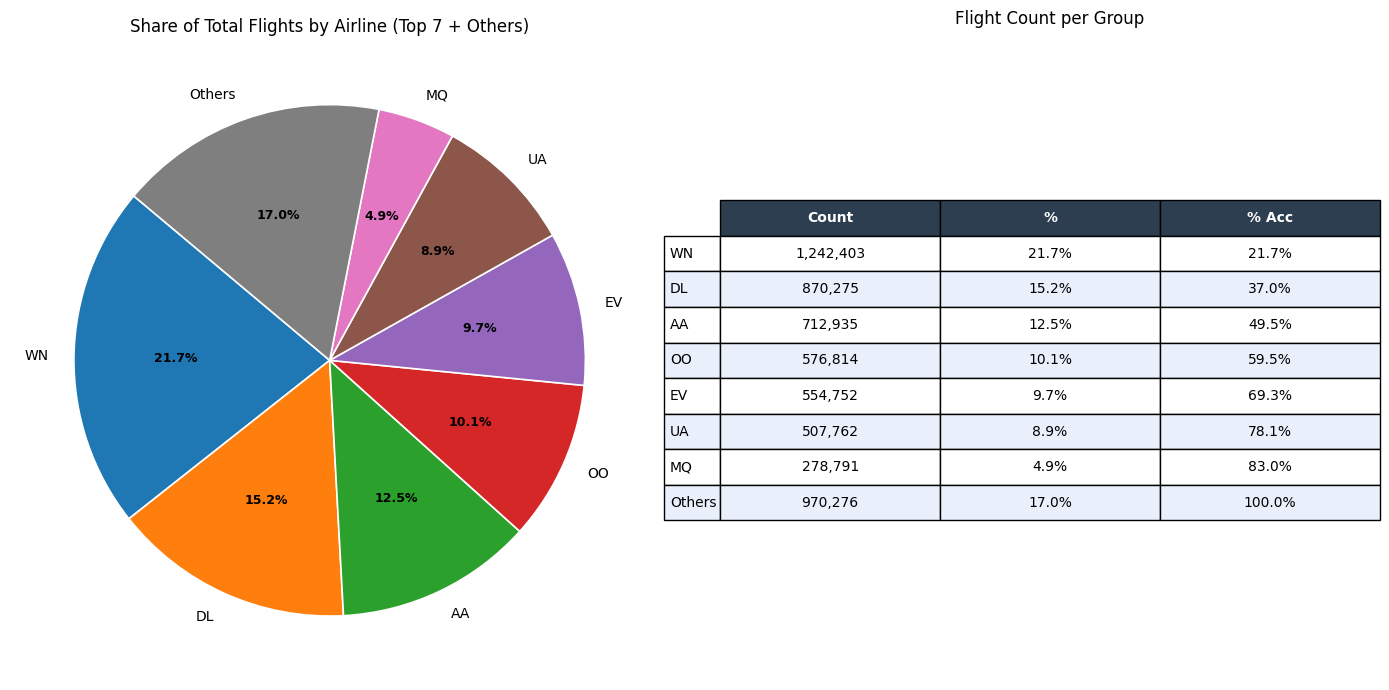

In [30]:
import matplotlib.pyplot as plt

flight_counts = (
    df_base
    .group_by("AIRLINE")
    .agg(pl.len().alias("COUNT"))
    .sort("COUNT", descending=True)
)

top7   = flight_counts.head(7)
others = flight_counts.tail(len(flight_counts) - 7)

labels = top7["AIRLINE"].to_list() + ["Others"]
sizes  = top7["COUNT"].to_list()   + [others["COUNT"].sum()]

total  = sum(sizes)
pcts   = [s / total * 100 for s in sizes]
acc    = []
cum    = 0.0
for p in pcts:
    cum += p
    acc.append(cum)

fig, (ax_pie, ax_tbl) = plt.subplots(1, 2, figsize=(14, 7),
                                      gridspec_kw={"width_ratios": [1.2, 1]})

wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.tab10.colors[:len(labels)],
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax_pie.set_title("Share of Total Flights by Airline (Top 7 + Others)")

table_data = [
    [f"{c:,}", f"{p:.1f}%", f"{a:.1f}%"]
    for c, p, a in zip(sizes, pcts, acc)
]

tbl = ax_tbl.table(
    cellText=table_data,
    rowLabels=labels,
    colLabels=["Count", "%", "% Acc"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# header styling
for col in range(3):
    tbl[0, col].set_facecolor("#2c3e50")
    tbl[0, col].set_text_props(color="white", fontweight="bold")

# row label styling + alternating row colors
for row in range(1, len(labels) + 1):
    bg = "#eaf0fb" if row % 2 == 0 else "white"
    tbl[row, -1].set_facecolor(bg)   # row label cell
    for col in range(3):
        tbl[row, col].set_facecolor(bg)

ax_tbl.axis("off")
ax_tbl.set_title("Flight Count per Group", pad=12)

plt.tight_layout()
plt.show()

## Analise estatística dos voos atrasados

In [31]:
# dataframe contendo apenas os atrasos.
df_delay_series = (
    df_base
    .filter(pl.col("ARRIVAL_DELAY") > 30)
    .select("ARRIVAL_DELAY")
)

# Proporção de voos atrasados (ARRIVAL_DELAY > 30 minutos)
portion = len(df_delay_series) / len(df_base) * 100
print(f"Portion of delayed flights (ARRIVAL_DELAY > 30): {portion:.2f}%")

# Estatísticas descritivas para a coluna ARRIVAL_DELAY
summary = df_delay_series.select(
    pl.col("ARRIVAL_DELAY").count().alias("Count"),
    pl.col("ARRIVAL_DELAY").mean().alias("Mean"),
    pl.col("ARRIVAL_DELAY").median().alias("Median"),
    pl.col("ARRIVAL_DELAY").std().alias("Std Dev"),
    pl.col("ARRIVAL_DELAY").min().alias("Min"),
    pl.col("ARRIVAL_DELAY").max().alias("Max"),
    pl.col("ARRIVAL_DELAY").quantile(0.25).alias("Q1 (25%)"),
    pl.col("ARRIVAL_DELAY").quantile(0.75).alias("Q3 (75%)"),
    pl.col("ARRIVAL_DELAY").skew().alias("Skewness"),
    pl.col("ARRIVAL_DELAY").kurtosis().alias("Kurtosis"),
)

print(summary.transpose(include_header=True, header_name="Statistic", column_names=["Value"]))

Portion of delayed flights (ARRIVAL_DELAY > 30): 11.07%
shape: (10, 2)
┌───────────┬───────────┐
│ Statistic ┆ Value     │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Count     ┆ 632697.0  │
│ Mean      ┆ 84.485936 │
│ Median    ┆ 61.0      │
│ Std Dev   ┆ 72.870236 │
│ Min       ┆ 31.0      │
│ Max       ┆ 1971.0    │
│ Q1 (25%)  ┆ 42.0      │
│ Q3 (75%)  ┆ 100.0     │
│ Skewness  ┆ 4.683755  │
│ Kurtosis  ┆ 44.39898  │
└───────────┴───────────┘


### Observações
Dentre os voos considerados atrasados (11% da amostra) temos:
- 25% (Q1) tem atraso até 42min
- 50% (Q2 - mediana) tem atraso de até 61min
- 75% (Q3) tem atraso de até 100min
- A assimetria (skewness) positiva também indica cauda longa a direita.
- A mediana menor do que a média concentração das amostras a esquerda dela.
- A curtose leptocurtica indica concentração das amostras concentradas próxima à média.

Sendo a média e o desvio padrão 85min e 73min respectivamente, 97,72% das amostras dos voos considerados atrasados (μ + 2 $\sigma$), ficaram abaixo de 231min de atraso (3,85h)

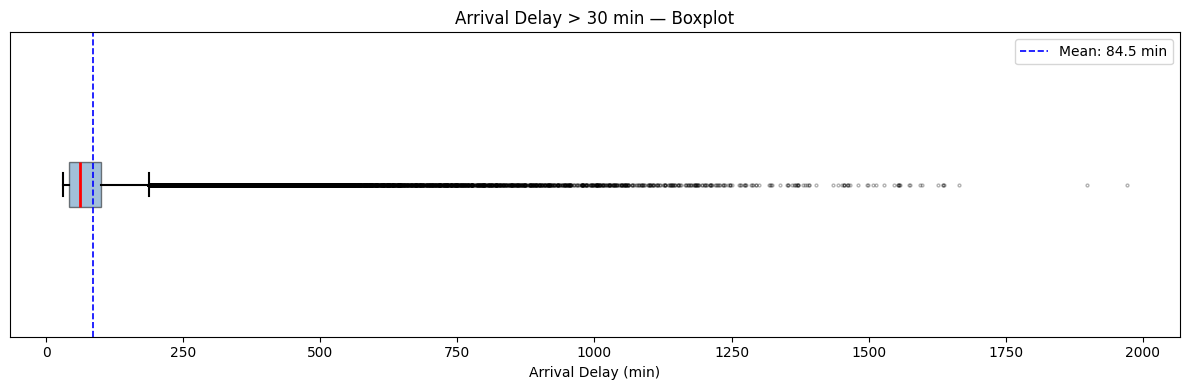

In [32]:
data   = df_delay_series["ARRIVAL_DELAY"].to_numpy()
mean   = float(summary["Mean"][0])
median = float(summary["Median"][0])
q1     = float(summary["Q1 (25%)"][0])
q3     = float(summary["Q3 (75%)"][0])

fig, ax = plt.subplots(figsize=(12, 4))
bp = ax.boxplot(data, vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.5),
                medianprops=dict(color="red", lw=2),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.3, color="gray"))
ax.axvline(mean, color="blue", linestyle="--", lw=1.2, label=f"Mean: {mean:.1f} min")
ax.set_xlabel("Arrival Delay (min)")
ax.set_title("Arrival Delay > 30 min — Boxplot")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

# Atrasos por frequência de ocorrência por companhia

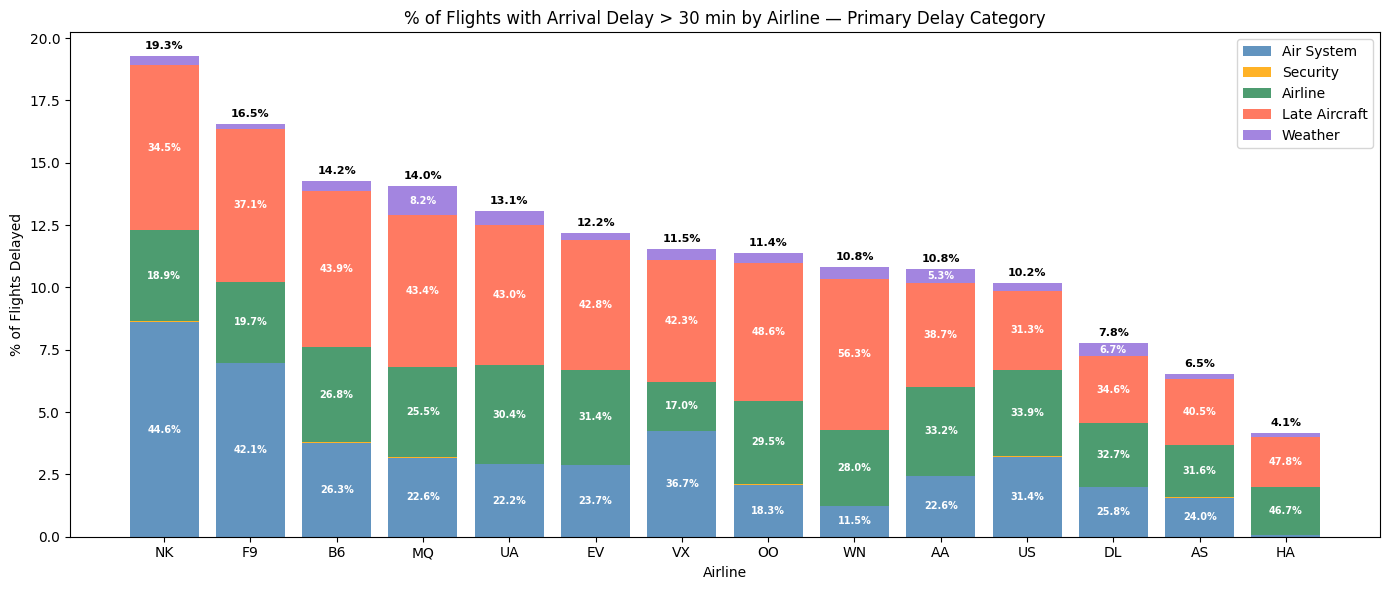

In [33]:
import matplotlib.pyplot as plt
import numpy as np

delay_cols   = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
delay_labels = ["Air System", "Security", "Airline", "Late Aircraft", "Weather"]
delay_colors = ["steelblue", "orange", "seagreen", "tomato", "mediumpurple"]

total_per_airline = (
    df_base
    .group_by("AIRLINE")
    .agg(pl.len().alias("TOTAL"))
)

# For each delayed flight, pick the category with the highest value as the primary reason.
# Ties are broken by column order. Flights where all columns are 0/null → "Unknown".
df_delayed_reason = (
    df_base
    .filter(pl.col("ARRIVAL_DELAY") > 30)
    .with_columns([pl.col(c).fill_null(0) for c in delay_cols])
    .with_columns(
        pl.max_horizontal(*[pl.col(c) for c in delay_cols]).alias("_MAX_VAL")
    )
    .with_columns(
        pl.when((pl.col("AIR_SYSTEM_DELAY") == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Air System"))
        .when((pl.col("SECURITY_DELAY") == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Security"))
        .when((pl.col("AIRLINE_DELAY") == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Airline"))
        .when((pl.col("LATE_AIRCRAFT_DELAY") == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Late Aircraft"))
        .when((pl.col("WEATHER_DELAY") == pl.col("_MAX_VAL")) & (pl.col("_MAX_VAL") > 0)).then(pl.lit("Weather"))
        .otherwise(pl.lit("Unknown"))
        .alias("PRIMARY_DELAY")
    )
    .drop("_MAX_VAL")
)

df_delayed_by_airline = (
    df_delayed_reason
    .group_by("AIRLINE")
    .agg(pl.len().alias("DELAYED"))
)

df_count = (
    df_delayed_reason
    .group_by(["AIRLINE", "PRIMARY_DELAY"])
    .agg(pl.len().alias("COUNT"))
    .join(total_per_airline,   on="AIRLINE")
    .join(df_delayed_by_airline, on="AIRLINE")
    .with_columns(
        # bar height: segment as % of airline's total flights
        (pl.col("COUNT") / pl.col("TOTAL")   * 100).alias("PCT_OF_TOTAL"),
        # label: segment as % of airline's own delayed flights
        (pl.col("COUNT") / pl.col("DELAYED") * 100).alias("PCT_OF_DELAYED"),
    )
)

airline_totals = (
    df_count
    .group_by("AIRLINE")
    .agg(pl.col("PCT_OF_TOTAL").sum().alias("TOTAL_PCT"))
    .sort("TOTAL_PCT", descending=True)
)
airlines_sorted = airline_totals["AIRLINE"].to_list()

has_unknown    = "Unknown" in df_count["PRIMARY_DELAY"].to_list()
all_categories = delay_labels + (["Unknown"] if has_unknown else [])
all_colors     = delay_colors  + (["gray"]    if has_unknown else [])

height_map = {(r["AIRLINE"], r["PRIMARY_DELAY"]): r["PCT_OF_TOTAL"]   for r in df_count.to_dicts()}
label_map  = {(r["AIRLINE"], r["PRIMARY_DELAY"]): r["PCT_OF_DELAYED"] for r in df_count.to_dicts()}
total_map  = {r["AIRLINE"]: r["TOTAL_PCT"] for r in airline_totals.to_dicts()}

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(airlines_sorted))

for cat, color in zip(all_categories, all_colors):
    heights = np.array([height_map.get((a, cat), 0.0) for a in airlines_sorted], dtype=float)
    labels  = [label_map.get((a, cat), 0.0) for a in airlines_sorted]
    bars = ax.bar(airlines_sorted, heights, bottom=bottom, label=cat, color=color, alpha=0.85)
    for bar, h, lbl in zip(bars, heights, labels):
        if lbl >= 5.0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{lbl:.1f}%",
                ha="center", va="center", fontsize=7, color="white", fontweight="bold"
            )
    bottom += heights

for i, airline in enumerate(airlines_sorted):
    ax.text(i, bottom[i] + 0.2, f"{total_map[airline]:.1f}%",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Airline")
ax.set_ylabel("% of Flights Delayed")
ax.set_title("% of Flights with Arrival Delay > 30 min by Airline — Primary Delay Category")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


NK é a companhia que tem mais atrasos em relação ao número de voos realizados. 19% dos seus voos atrasam, seguida pela F9 e B6.
A principal ocorrência de atraso para NK é o Air System ja para a B6 a principal razão é o Late Aircraft, por exemplo.

# Distribuição dos tempos de atraso por companhia

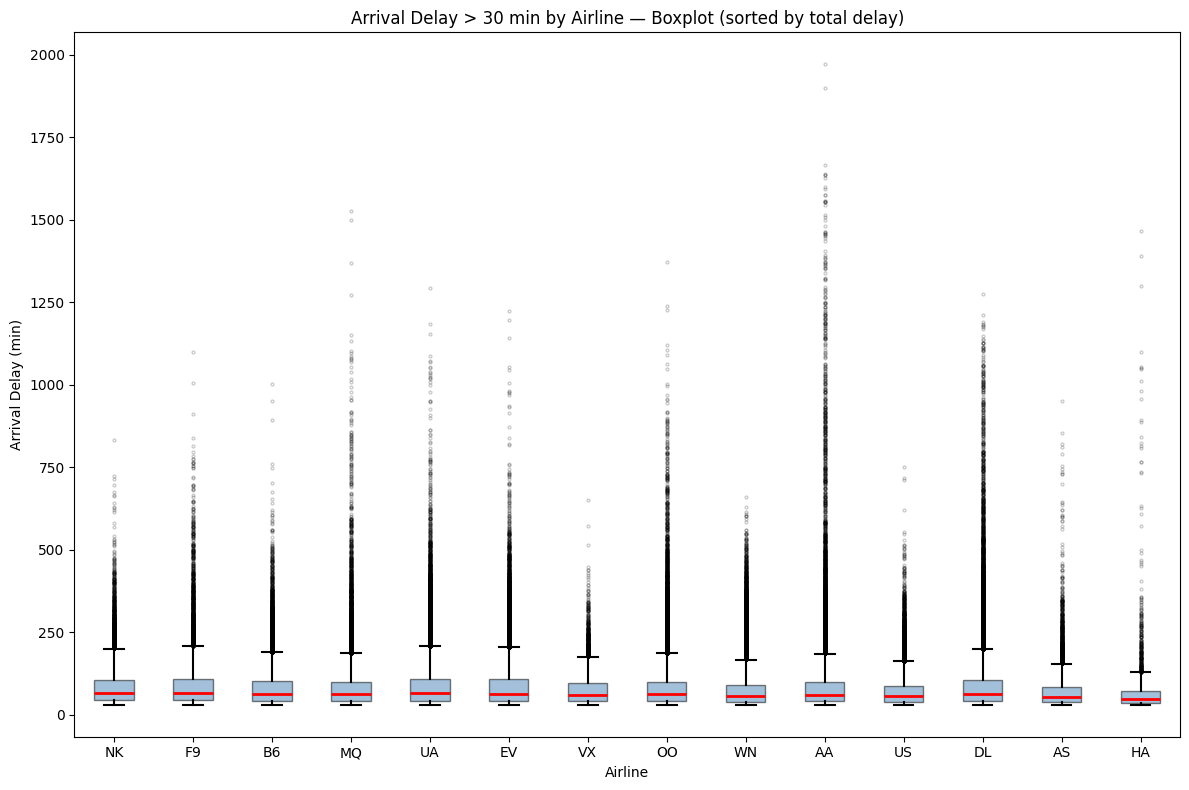

In [34]:
# Same airline order as the Delay Category Breakdown chart (sorted by total delay descending)
airlines = airline_totals["AIRLINE"].to_list()

data_by_airline = [
    df_delayed_reason
    .filter((pl.col("AIRLINE") == airline))
    ["ARRIVAL_DELAY"]
    .to_list()
    for airline in airlines
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_by_airline, vert=True, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.5),
           medianprops=dict(color="red", lw=2),
           whiskerprops=dict(lw=1.5),
           capprops=dict(lw=1.5),
           flierprops=dict(marker="o", markersize=2, alpha=0.2, color="gray"))
ax.set_xticks(range(1, len(airlines) + 1))
ax.set_xticklabels(airlines)
ax.set_ylabel("Arrival Delay (min)")
ax.set_xlabel("Airline")
ax.set_title("Arrival Delay > 30 min by Airline — Boxplot (sorted by total delay)")
plt.tight_layout()
plt.show()


Percebesse que no geral todas as companhias possuem uma distribuição do tempo de atraso semelhante, porém fica evidente o número de outliers existente para a AA.

# Aplicação do K-Means sobre as coordenadas de origem e destino das rotas

In [35]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. Load airport coordinates ---
airports = pd.read_csv('airports.csv')

# --- 2. Build route-level dataframe ---
routes = (
    df_base
    .group_by(["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"])
    .agg([
        pl.count("ARRIVAL_DELAY").alias("n_flights"),
        pl.col("ARRIVAL_DELAY").mean().alias("avg_delay"),
        (pl.col("ARRIVAL_DELAY") > 30).mean().alias("pct_delayed"),
    ])
)

# --- 3. Join coordinates for origin and destination ---
routes = routes.to_pandas()

routes = (
    routes
    .merge(
        airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']],
        left_on='ORIGIN_AIRPORT',
        right_on='IATA_CODE',
        how='left'
    )
    .rename(columns={'LATITUDE': 'ORIG_LAT', 'LONGITUDE': 'ORIG_LON'})
    .drop(columns='IATA_CODE')
    .merge(
        airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']],
        left_on='DESTINATION_AIRPORT',
        right_on='IATA_CODE',
        how='left'
    )
    .rename(columns={'LATITUDE': 'DEST_LAT', 'LONGITUDE': 'DEST_LON'})
    .drop(columns='IATA_CODE')
)

routes_companies = (
    df_base
    .group_by(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])
    .agg(pl.col('AIRLINE').unique().sort().alias('COMPANIES'))
    .to_pandas()
)

routes = routes.merge(
    routes_companies,
    on=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'],
    how='left'
)

# --- 3.1 Remove routes with missing coordinates before clustering ---
routes = routes.dropna(subset=['ORIG_LAT', 'ORIG_LON', 'DEST_LAT', 'DEST_LON']).copy()

# -------------------------
# --- KMEANS CLUSTERING ---
# -------------------------

# --- 4. Feature matrix: origin + destination coordinates ---
features = ['ORIG_LAT', 'ORIG_LON', 'DEST_LAT', 'DEST_LON']
X = routes[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5. Elbow method - Find optimal number of clusters ---
inertias = {}
for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias[k] = km.inertia_

# Calculate the rate of change in inertia
inertia_values = list(inertias.values())
ks = list(inertias.keys())

# Calculate differences (rate of decrease)
differences = [inertia_values[i] - inertia_values[i+1] for i in range(len(inertia_values)-1)]

# Find the elbow: where the rate of decrease slows down the most
# Calculate second derivative to find the "bend"
second_diff = [differences[i] - differences[i+1] for i in range(len(differences)-1)]
elbow_idx = second_diff.index(max(second_diff))
optimal_k = ks[elbow_idx + 1]

print(f"Optimal number of clusters (elbow method): {optimal_k}")

# --- 6. Fit final model ---
km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km.fit(X_scaled)
routes['ROUTE_CLUSTER'] = km.labels_

# --- 7. Profile clusters by delay behavior ---
profile = routes.groupby('ROUTE_CLUSTER').agg(
    n_routes=('n_flights', 'count'),
    total_flights=('n_flights', 'sum'),
    avg_delay=('avg_delay', 'mean'),
    pct_delayed=('pct_delayed', 'mean')
).round(3)

print(profile)

Optimal number of clusters (elbow method): 3
               n_routes  total_flights  avg_delay  pct_delayed
ROUTE_CLUSTER                                                 
0                  1981        1969445      6.673        0.133
1                  1563        1916357      5.212        0.120
2                  1090        1336198      3.412        0.102


O método elbow determinou que a clusterização ótima seriam três cluster

# Plot das rotas por cluster

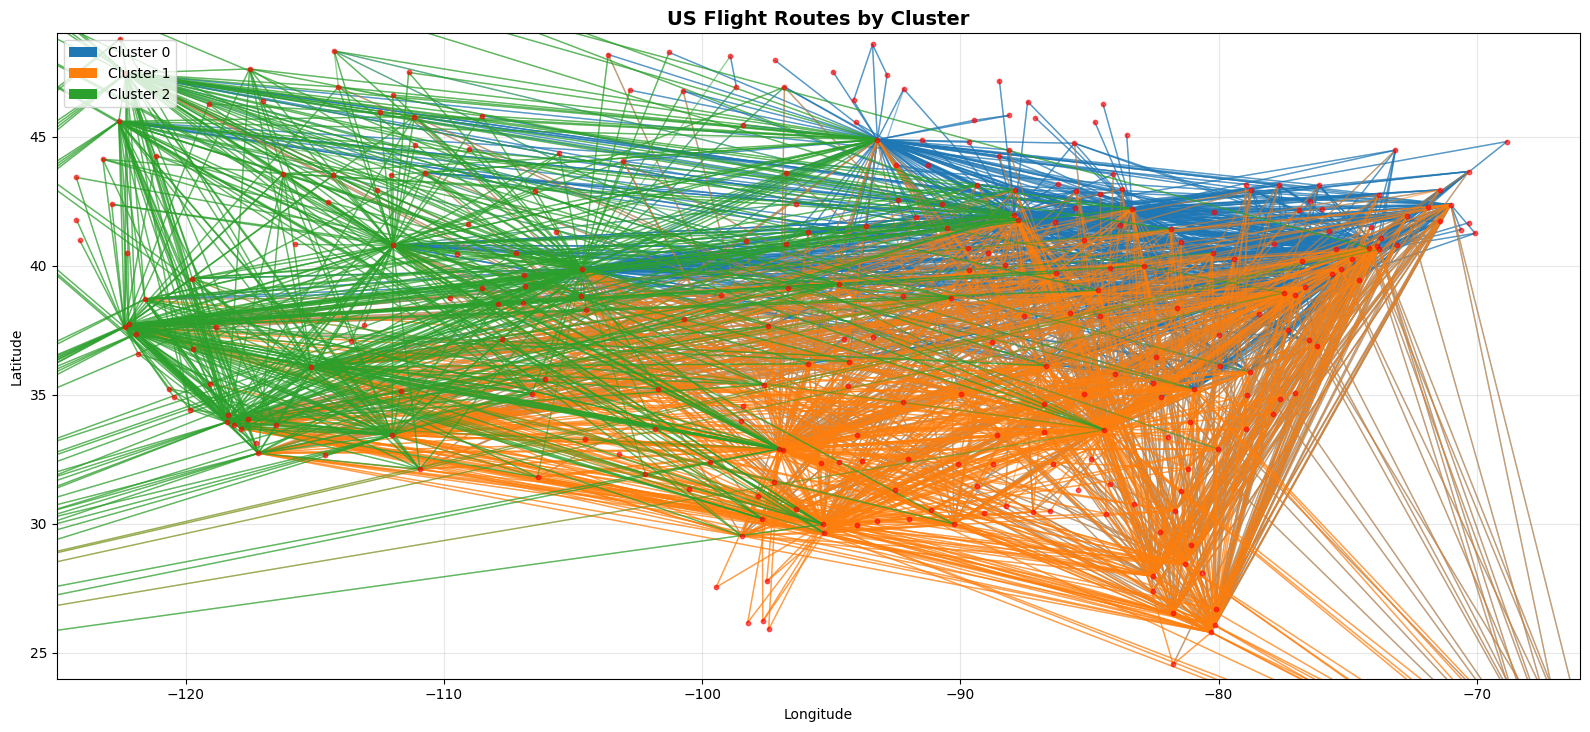

In [36]:
# --- Plot routes on US map colored by cluster ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 10))

# Define US map bounds (approximate)
us_bounds = {
    'min_lat': 24, 'max_lat': 49,
    'min_lon': -125, 'max_lon': -66
}

ax.set_xlim(us_bounds['min_lon'], us_bounds['max_lon'])
ax.set_ylim(us_bounds['min_lat'], us_bounds['max_lat'])
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('US Flight Routes by Cluster', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot routes colored by cluster
colors = plt.cm.tab10(range(10))
for cluster_id in sorted(routes['ROUTE_CLUSTER'].dropna().unique()):
    cluster_routes = routes[routes['ROUTE_CLUSTER'] == cluster_id]
    
    for _, route in cluster_routes.iterrows():
        ax.plot(
            [route['ORIG_LON'], route['DEST_LON']],
            [route['ORIG_LAT'], route['DEST_LAT']],
            color=colors[int(cluster_id) % len(colors)],
            alpha=0.5,
            linewidth=1
        )

# Plot airports
all_airports = set()
for _, row in routes.iterrows():
    all_airports.add((row['ORIG_LAT'], row['ORIG_LON']))
    all_airports.add((row['DEST_LAT'], row['DEST_LON']))

for lat, lon in all_airports:
    ax.scatter(lon, lat, c='red', s=10, alpha=0.6, zorder=5)

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i % len(colors)], label=f'Cluster {i}') 
                   for i in sorted(routes['ROUTE_CLUSTER'].dropna().unique())]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

Evidenciou-se que existem três regiões principais onde os voos são realizados pelas companhias: nordeste, sudeste e oeste.

# Cruzamento das regiões com as companhias

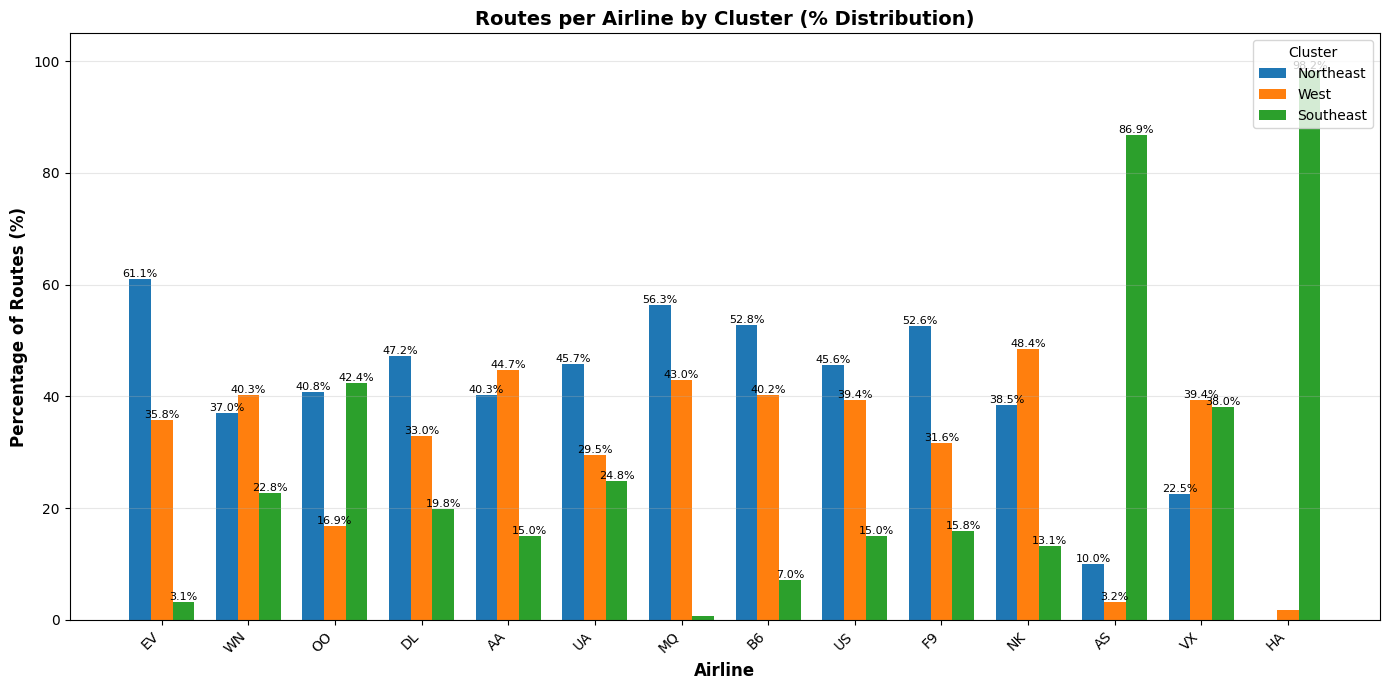

In [37]:
# --- Bar graph: Companies by Cluster (as percentages) ---
import pandas as pd
import numpy as np

cluster_names = {0: 'Northeast', 2: 'Southeast', 1: 'West'}

# Flatten companies tuple and create a row for each company-route combination
company_cluster_list = []
for _, row in routes.iterrows():
    for company in row['COMPANIES']:
        company_cluster_list.append({
            'COMPANY': company,
            'ROUTE_CLUSTER': int(row['ROUTE_CLUSTER']) if pd.notna(row['ROUTE_CLUSTER']) else None,
        })

company_cluster_df = pd.DataFrame(company_cluster_list)

# Count routes per company per cluster
routes_by_company_cluster = company_cluster_df.groupby(['COMPANY', 'ROUTE_CLUSTER']).size().reset_index(name='route_count')

# Pivot for easier plotting
pivot_data = routes_by_company_cluster.pivot(index='COMPANY', columns='ROUTE_CLUSTER', values='route_count').fillna(0)

# Calculate percentages for each airline (row-wise)
pivot_data_pct = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100

# Sort by total routes (use original pivot_data for sorting)
pivot_data['TOTAL'] = pivot_data.sum(axis=1)
airlines_sorted = pivot_data.sort_values('TOTAL', ascending=False).index
pivot_data_pct = pivot_data_pct.loc[airlines_sorted]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(pivot_data_pct.index))
width = 0.25
colors = plt.cm.tab10(range(len(pivot_data_pct.columns)))

for i, cluster in enumerate(sorted(pivot_data_pct.columns)):
    offset = width * (i - len(pivot_data_pct.columns) / 2 + 0.5)
    cluster_label = cluster_names.get(int(cluster), f'Cluster {int(cluster)}')
    bars = ax.bar(x + offset, pivot_data_pct[cluster], width, label=cluster_label, color=colors[i])
    
    # Add percentage labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 3:  # Only show label if bar is tall enough
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Airline', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Routes (%)', fontsize=12, fontweight='bold')
ax.set_title('Routes per Airline by Cluster (% Distribution)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_data_pct.index, rotation=45, ha='right')
ax.legend(title='Cluster', loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Exploração das regiões onde as companhias voam com as principais razões de atraso

In [38]:
# Build comprehensive summary table with cluster percentages and delay reasons
delay_labels = ["Air System", "Security", "Airline", "Late Aircraft", "Weather"]
delay_labels_display = ["Air System", "Security", "Airline Delay", "Late Aircraft", "Weather"]

summary_data = []
for airline in top7["AIRLINE"].to_list():
    row_data = {'Airline': airline}
    
    # Add cluster percentages
    for cluster in sorted(pivot_data_pct.columns):
        cluster_name = cluster_names.get(int(cluster), f'Cluster {int(cluster)}')
        row_data[cluster_name] = f"{pivot_data_pct.loc[airline, cluster]:.2f}%"
    
    # Add delay reason percentages
    for delay_label, delay_label_display in zip(delay_labels, delay_labels_display):
        pct = label_map.get((airline, delay_label), 0.0)
        row_data[delay_label_display] = f"{pct:.2f}%"
    
    summary_data.append(row_data)

summary_table_full = pd.DataFrame(summary_data)

# Reorder columns to put Airline first
cols = ['Airline'] + [col for col in summary_table_full.columns if col != 'Airline']
summary_table_full = summary_table_full[cols]

# Set Airline as index for cleaner display
summary_table_full = summary_table_full.set_index('Airline')

print("\nRoutes per Airline by Cluster with Delay Reasons (%):")
print(summary_table_full.to_string())


Routes per Airline by Cluster with Delay Reasons (%):
        Northeast    West Southeast Air System Security Airline Delay Late Aircraft Weather
Airline                                                                                    
WN         36.96%  40.29%    22.75%     11.45%    0.08%        27.99%        56.27%   4.22%
DL         47.24%  32.99%    19.77%     25.81%    0.07%        32.74%        34.64%   6.73%
AA         40.31%  44.70%    14.99%     22.59%    0.23%        33.16%        38.72%   5.30%
OO         40.77%  16.87%    42.36%     18.33%    0.16%        29.51%        48.58%   3.42%
EV         61.07%  35.80%     3.12%     23.69%    0.00%        31.41%        42.79%   2.12%
UA         45.73%  29.49%    24.79%     22.20%    0.03%        30.39%        43.02%   4.37%
MQ         56.31%  42.99%     0.70%     22.59%    0.21%        25.54%        43.45%   8.21%



Correlation between Delay Reasons and Geographic Clusters:
               Southeast   West  Northeast
Air System        -0.413  0.043      0.611
Security           0.000  0.260     -0.282
Airline Delay      0.142 -0.084     -0.135
Late Aircraft      0.323 -0.127     -0.378
Weather           -0.328  0.431      0.057


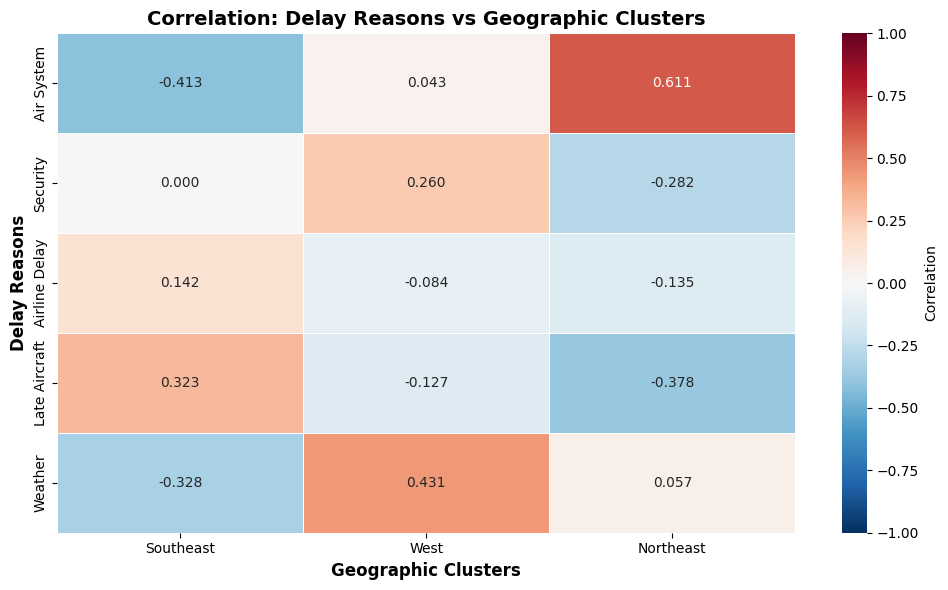

In [39]:
# Correlation analysis: Clusters vs Delay Reasons
import numpy as np
import pandas as pd

# Create a numeric version of the table (remove % and convert to float)
summary_numeric = summary_table_full.copy()
for col in summary_numeric.columns:
    summary_numeric[col] = summary_numeric[col].str.rstrip('%').astype(float)

# Extract cluster and delay columns
cluster_cols = ['Southeast', 'West', 'Northeast']
delay_cols = ['Air System', 'Security', 'Airline Delay', 'Late Aircraft', 'Weather']

# Calculate correlation matrix between all columns
all_cols = cluster_cols + delay_cols
correlation_data = summary_numeric[all_cols]
correlation_matrix = correlation_data.corr()

# Extract only the correlations between clusters and delays
correlation_clusters_delays = correlation_matrix.loc[delay_cols, cluster_cols]

print("\nCorrelation between Delay Reasons and Geographic Clusters:")
print(correlation_clusters_delays.round(3))

# Visualize with heatmap
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(correlation_clusters_delays, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation: Delay Reasons vs Geographic Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Geographic Clusters', fontsize=12, fontweight='bold')
ax.set_ylabel('Delay Reasons', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Sete companhias performam 83% de todos os voos dos EUA. Existe uma leve correlação entre os atrasos dessas sete companhias causados por Air System que concentram seus voos no setor Nordeste.

In [40]:
# Add route_cluster column from routes to df_base
df_base = df_base.join(
    pl.from_pandas(routes[['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE_CLUSTER']]),
    left_on=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'],
    right_on=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'],
    how='left'
)

df_base.head()

DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ROUTE_CLUSTER
str,str,cat,str,str,str,datetime[μs],datetime[μs],i64,i64,datetime[μs],i64,i64,i64,i64,datetime[μs],i64,datetime[μs],datetime[μs],i64,i64,cat,str,i64,i64,i64,i64,i64,i32
"""Wed""","""AS""","""98""","""N407AS""","""ANC""","""SEA""",2015-01-01 00:05:00,2014-12-31 23:54:00,-11,21,2015-01-01 00:15:00,205,194,169,1448,2015-01-01 03:04:00,4,2015-01-01 03:30:00,2015-01-01 03:08:00,-22,0,"""0""",null,null,null,null,null,null,2
"""Wed""","""AA""","""2336""","""N3KUAA""","""LAX""","""PBI""",2015-01-01 00:10:00,2015-01-01 00:02:00,-8,12,2015-01-01 00:14:00,280,279,263,2330,2015-01-01 04:37:00,4,2015-01-01 04:50:00,2015-01-01 04:41:00,-9,0,"""0""",null,null,null,null,null,null,1
"""Wed""","""US""","""840""","""N171US""","""SFO""","""CLT""",2015-01-01 00:20:00,2015-01-01 00:18:00,-2,16,2015-01-01 00:34:00,286,293,266,2296,2015-01-01 05:00:00,11,2015-01-01 05:06:00,2015-01-01 05:11:00,5,0,"""0""",null,null,null,null,null,null,1
"""Wed""","""AA""","""258""","""N3HYAA""","""LAX""","""MIA""",2015-01-01 00:20:00,2015-01-01 00:15:00,-5,15,2015-01-01 00:30:00,285,281,258,2342,2015-01-01 04:48:00,8,2015-01-01 05:05:00,2015-01-01 04:56:00,-9,0,"""0""",null,null,null,null,null,null,1
"""Wed""","""AS""","""135""","""N527AS""","""SEA""","""ANC""",2015-01-01 00:25:00,2015-01-01 00:24:00,-1,11,2015-01-01 00:35:00,235,215,199,1448,2015-01-01 03:54:00,5,2015-01-01 04:20:00,2015-01-01 03:59:00,-21,0,"""0""",null,null,null,null,null,null,2


In [41]:
# Build ML-ready dataframe with all features
import numpy as np

# --- 1. Add Season based on month ---
def get_season(month):
    """Map month (1-12) to season: win (12,1,2), spr (3,4,5), sum (6,7,8), aut (9,10,11)"""
    if month in [12, 1, 2]:
        return "win"
    elif month in [3, 4, 5]:
        return "spr"
    elif month in [6, 7, 8]:
        return "sum"
    else:
        return "aut"

df_ml = (
    df_base
    .with_columns(
        pl.col("SCHEDULED_DEPARTURE").dt.month().alias("_MONTH")
    )
    .with_columns(
        pl.col("_MONTH")
        .map_elements(get_season, return_dtype=pl.String)
        .alias("Season")
    )
    .drop("_MONTH")
)

# --- 2. Create sine/cosine features for times ---
# Convert time to minutes since midnight, then to radians [0, 2π)
df_ml = (
    df_ml
    .with_columns([
        # Scheduled departure sine/cosine
        (((pl.col("SCHEDULED_DEPARTURE").dt.hour() * 60 + pl.col("SCHEDULED_DEPARTURE").dt.minute()) 
          / (24 * 60)) * 2 * np.pi).sin().alias("Scheduled_departure_sin"),
        
        (((pl.col("SCHEDULED_DEPARTURE").dt.hour() * 60 + pl.col("SCHEDULED_DEPARTURE").dt.minute()) 
          / (24 * 60)) * 2 * np.pi).cos().alias("Scheduled_departure_cos"),
        
        # Scheduled arrival sine/cosine
        (((pl.col("SCHEDULED_ARRIVAL").dt.hour() * 60 + pl.col("SCHEDULED_ARRIVAL").dt.minute()) 
          / (24 * 60)) * 2 * np.pi).sin().alias("Scheduled_arrival_sin"),
        
        (((pl.col("SCHEDULED_ARRIVAL").dt.hour() * 60 + pl.col("SCHEDULED_ARRIVAL").dt.minute()) 
          / (24 * 60)) * 2 * np.pi).cos().alias("Scheduled_arrival_cos"),
    ])
)

# --- 3. Calculate Estimated Flight Time (in minutes) ---
df_ml = (
    df_ml
    .with_columns(
        ((pl.col("SCHEDULED_ARRIVAL") - pl.col("SCHEDULED_DEPARTURE"))
         .dt.total_minutes()
         .alias("Estimated_flight_time"))
    )
)

# --- 4. Select and rename final columns ---
df_final = (
    df_ml
    .select([
        "DAY_OF_WEEK",
        "Season",
        "AIRLINE",
        "ROUTE_CLUSTER",
        "Scheduled_departure_sin",
        "Scheduled_departure_cos",
        "Scheduled_arrival_sin",
        "Scheduled_arrival_cos",
        "Estimated_flight_time",
        "DISTANCE",
        "ARRIVAL_DELAY"
    ])
    .rename({
        "DAY_OF_WEEK": "Day_of_week",
        "AIRLINE": "Airline",
        "ROUTE_CLUSTER": "Route_Cluster",
        "DISTANCE": "Distance",
        "ARRIVAL_DELAY": "Arrival_delay"
    })
)

# Display results
print(f"✓ ML dataframe built successfully!")
print(f"\n  Shape: {df_final.shape}")
print(f"\n  Columns: {df_final.columns}")
print(f"\nFirst 10 rows:")
print(df_final.head(10))
print(f"\nData types:")
print(df_final.schema)
print(f"\nBasic statistics:")
print(df_final.describe())

✓ ML dataframe built successfully!

  Shape: (5714008, 11)

  Columns: ['Day_of_week', 'Season', 'Airline', 'Route_Cluster', 'Scheduled_departure_sin', 'Scheduled_departure_cos', 'Scheduled_arrival_sin', 'Scheduled_arrival_cos', 'Estimated_flight_time', 'Distance', 'Arrival_delay']

First 10 rows:
shape: (10, 11)
┌────────────┬────────┬─────────┬────────────┬───┬────────────┬────────────┬──────────┬────────────┐
│ Day_of_wee ┆ Season ┆ Airline ┆ Route_Clus ┆ … ┆ Scheduled_ ┆ Estimated_ ┆ Distance ┆ Arrival_de │
│ k          ┆ ---    ┆ ---     ┆ ter        ┆   ┆ arrival_co ┆ flight_tim ┆ ---      ┆ lay        │
│ ---        ┆ str    ┆ str     ┆ ---        ┆   ┆ s          ┆ e          ┆ i64      ┆ ---        │
│ str        ┆        ┆         ┆ i32        ┆   ┆ ---        ┆ ---        ┆          ┆ i64        │
│            ┆        ┆         ┆            ┆   ┆ f64        ┆ i64        ┆          ┆            │
╞════════════╪════════╪═════════╪════════════╪═══╪════════════╪════════════╪═══

In [42]:
# Save df_final to parquet file
import os

df_final.write_parquet("df_final_ml_features.parquet")
print(f"✓ Successfully saved df_final to 'df_final_ml_features.parquet'")
print(f"  File size: {os.path.getsize('df_final_ml_features.parquet') / 1024 / 1024:.2f} MB")

✓ Successfully saved df_final to 'df_final_ml_features.parquet'
  File size: 41.22 MB
